In [13]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import pandas                  as pd
import numpy                   as np
import matplotlib.pyplot       as plt
import seaborn                 as sns
import statsmodels.api         as sm
import statsmodels.formula.api as smf

# This statement allow to display plot without asking to 
%matplotlib inline

# always make it pretty 
plt.style.use('ggplot')

In [14]:
df = pd.read_csv("Data_MLB_2025_StatcastPostseason_PitchByPitch_20251102a.csv")

print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(list(df.columns))

Rows: 14096, Columns: 95
['game_year', 'game_date', 'player_name', 'pitcher', 'batter', 'balls', 'strikes', 'inning', 'inning_topbot', 'at_bat_number', 'pitch_number', 'events', 'pitch_type', 'pitch_name', 'release_speed', 'release_pos_x', 'release_pos_z', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'hc_x', 'hc_y', 'tfs_deprecated', 'tfs_zulu_deprecated', 'fielder_2', 'fielder_2.1', 'umpire', 'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed', 'release_spin_rate', 'release_extension', 'game_pk', 'fielder_2.2', 'fielder_2.3', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y', 'estimated_ba_using_sp

The following are the columns of the dataset.

**game_year**: Year it took place

**game_date**: Date of the game

**pitch_type**: The type of pitch derived from Statcast

**events**: Event of the resulting plate appearance

**description**: Description of the resulting pitch

**launch_speed**: Exit velocity of the batted ball as tracked by Statcast. For batted balls not tracked directly, estimates are included based on Statcast's estimation process

**pitch_name**: The name of the pitch derived from the Statcast data

**home_score**: Pre-pitch home team score

**away_score**: Pre-pitch away team score

**bat_score**: Pre-pitch batting team score

**fld_score**: Pre-pitch fielding team score

**if_fielding_alignment**: Infield fielding alignment at the time of the pitch

**of_fielding_alignment**: Outfield fielding alignment at the time of the pitch

**spin_axis**: Spin axis in the 2D X–Z plane in degrees from 0–360 (180 represents pure backspin, 0 represents pure topspin)

**effective_speed**: Derived speed based on the extension of the pitcher's release

**release_spin_rate**: Release spin rate (TBD in original source)

**release_extension**: Release extension of pitch in feet as tracked by Statcast

**release_pos_y**: Release position of pitch measured in feet from the catcher's perspective

**at_bat_number**: Plate appearance number within the game

**player_name**: Player's name tied to the event

**batter**: MLB player ID for the batter tied to the play event

**pitcher**: MLB player ID for the pitcher tied to the play event

**pfx_x**: Horizontal movement in feet from the catcher's perspective

**release_speed**: Pitch velocity. Velocities from 2008–16 are via Pitch F/X (adjusted); velocities from 2017 onward are Statcast out-of-hand measurements

**release_pos_x**: Horizontal release position in feet from the catcher's perspective

**release_pos_z**: Vertical release position in feet from the catcher's perspective

**spin_dir**: Deprecated field from the older tracking system

**zone**: Zone location of the ball when it crosses the plate from the catcher's perspective

**p_throws**: Hand the pitcher throws with

**stand**: Batter's side of the plate (left/right)

**balls**: Pre-pitch number of balls in the count

**strikes**: Pre-pitch number of strikes in the count

**pfx_z**: Vertical movement in feet from the catcher's perspective

**plate_x**: Horizontal position of the ball as it crosses home plate from the catcher's perspective

**plate_z**: Vertical position of the ball as it crosses home plate from the catcher's perspective

**vx0**: Velocity of the pitch in x-dimension (ft/s), determined at y=50 ft

**vy0**: Velocity of the pitch in y-dimension (ft/s), determined at y=50 ft

**vz0**: Velocity of the pitch in z-dimension (ft/s), determined at y=50 ft

**ax**: Acceleration in x-dimension (ft/s^2), determined at y=50 ft

**ay**: Acceleration in y-dimension (ft/s^2), determined at y=50 ft

**az**: Acceleration in z-dimension (ft/s^2), determined at y=50 ft

## Data Types & Duplicates

In [15]:
print("Data types:")
print(df.dtypes.value_counts().to_string())
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"game_date dtype: {df['game_date'].dtype} - needs parsing to datetime")

Data types:
float64    48
int64      30
str        17
Exact duplicate rows: 0
game_date dtype: str - needs parsing to datetime


In [16]:
cols_dropped = list(df.columns[df.isna().all()])
print(f'Columns to drop: \n{list(df.columns[df.isna().all()])}')

df.drop(columns=cols_dropped, inplace=True)


Columns to drop: 
['spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'tfs_deprecated', 'tfs_zulu_deprecated', 'umpire', 'sv_id']


## Filter to Blue Jays Pitching Only

When Toronto is the **home** team, their pitchers throw in the **Top** of the inning. When Toronto is the **away** team, their pitchers throw in the **Bot** of the inning.

In [17]:
bj_df = df[
    ((df["home_team"] == "TOR") & (df["inning_topbot"] == "Top")) |
    ((df["away_team"] == "TOR") & (df["inning_topbot"] == "Bot"))
]

#This line passes variables across notebooks
%store bj_df

print(f"Blue Jays pitching rows: {bj_df.shape[0]:}")
print(f"Unique games: {bj_df['game_pk'].nunique()}")
print(f"Unique pitchers (by ID): {bj_df['pitcher'].nunique()}")


Stored 'bj_df' (DataFrame)
Blue Jays pitching rows: 2788
Unique games: 18
Unique pitchers (by ID): 15


## Missing Values — Blue Jays Pitching Subset

In [18]:
null = bj_df.isnull().sum()
null_percent = (bj_df.isnull().sum() / len(bj_df) * 100).round(2)
null_df = pd.DataFrame({"missing_count": null, "missing_percent": null_percent})
null_df = null_df[null_df["missing_count"] > 0].sort_values("missing_percent", ascending=False)
print(f"Columns with missing values: {len(null_df)} out of {bj_df.shape[1]}\n")
null_df

Columns with missing values: 20 out of 87



,missing_count,missing_percent
on_3b,2599,93.22
estimated_ba_using_speedangle,2340,83.93
launch_speed_angle,2340,83.93
bb_type,2337,83.82
hc_x,2337,83.82
hc_y,2337,83.82
on_2b,2315,83.03
hit_location,2188,78.48
estimated_woba_using_speedangle,2092,75.04
woba_denom,2090,74.96


## Build an Analysis-Ready Blue Jays Pitching Dataset

Turn `bj_df` into a cleaned dataframe that is easier to use for EDA and modeling. In this section we:

1. parse dates and sort the data chronologically,
2. classify missing values based on baseball context,
3. keep the columns that are most useful for our research questions, and
4. create helper variables that will be reused in later notebooks.

This is important because many missing values in Statcast are **structural** rather than data errors.

In [19]:
# Step 1: Parse dates and sort the Blue Jays pitching subset in game order.
#
# Why this block exists:
# - `game_date` was read in as text, but we will want it as a real datetime.
# - Chronological sorting makes later trend analysis and lag-feature work safer.

bj_df = bj_df.copy()
bj_df["game_date"] = pd.to_datetime(bj_df["game_date"])

sort_cols = [col for col in ["game_date", "game_pk", "at_bat_number", "pitch_number"] if col in bj_df.columns]
bj_df = bj_df.sort_values(sort_cols).reset_index(drop=True)

print(f"Date range: {bj_df['game_date'].min().date()} to {bj_df['game_date'].max().date()}")
print(f"Rows after sorting: {len(bj_df)}")
print(f"Duplicate rows after preprocessing: {bj_df.duplicated().sum()}")

Date range: 2025-10-04 to 2025-11-01
Rows after sorting: 2788
Duplicate rows after preprocessing: 0


## Create a Cleaner Analysis Table

This block keeps the variables that are most useful for Blue Jays pitching analysis and creates a few helper features.

The helper features are designed to support both of your downstream directions:

- performance analysis, such as strike rate and whiff rate,
- pitch-sequencing or pitch-type prediction, where count, previous context, and base state matter.

We also simplify the raw ball-strike count into a more baseball-oriented representation:

- `count_leverage`: whether the count favors the pitcher, favors the hitter, or is even,
- `has_two_strikes`: whether the batter already has two strikes.

This makes the count easier to interpret in plots and summaries while still preserving one of the most important strategic situations in baseball: the two-strike count.

We are not imputing everything here. Instead, we keep a compact, analysis-ready dataset and leave specialized treatment for later notebooks if needed.

In [ ]:
# Keep core variables 

# - smaller dataframe focused on pitch context, pitcher identity,
#   count state, and key Statcast movement / command variables.
# - adds binary indicators that will be reused in later EDA and models.

core_columns = [
    "game_date", "game_pk", "inning", "inning_topbot", "at_bat_number", "pitch_number",
    "pitcher", "player_name", "stand", "p_throws",
    "balls", "strikes", "outs_when_up",
    "home_team", "away_team", "bat_score", "fld_score",
    "pitch_type", "pitch_name", "release_speed", "release_spin_rate",
    "release_pos_x", "release_pos_z", "pfx_x", "pfx_z", "plate_x", "plate_z",
    "zone", "description", "type", "events",
    "if_fielding_alignment", "of_fielding_alignment",
    "on_1b", "on_2b", "on_3b"
]

available_core_columns = [col for col in core_columns if col in bj_df.columns]
bj_clean = bj_df[available_core_columns].copy()

# Count state combines balls and strikes into one game-context variable.
bj_clean["count_state"] = bj_clean["balls"].astype(str) + "-" + bj_clean["strikes"].astype(str)

# We keep the raw count, but also create a simpler count category that is easier
# to analyze and explain in visuals.
#
# pitcher_ahead: the pitcher has more leverage in the count
# hitter_ahead: the hitter has more leverage in the count
# even: the count is neutral
bj_clean["count_leverage"] = np.select(
    [
        bj_clean["balls"] > bj_clean["strikes"],
        bj_clean["balls"] < bj_clean["strikes"],
        bj_clean["balls"] == bj_clean["strikes"]
    ],
    ["hitter_ahead", "pitcher_ahead", "even"],
    default="other"
)

# Two-strike counts often change pitch selection and pitcher intent, so we keep
# that situation as a separate binary feature.
bj_clean["has_two_strikes"] = bj_clean["strikes"].eq(2).astype(int)

# Score differential is from Toronto's pitching perspective.
bj_clean["score_diff"] = bj_clean["fld_score"] - bj_clean["bat_score"]

# Binary pitch outcome flags
bj_clean["is_strike"] = bj_clean["type"].eq("S").astype(int)
bj_clean["is_whiff"] = bj_clean["description"].isin(["swinging_strike", "swinging_strike_blocked"]).astype(int)
bj_clean["is_in_play"] = bj_clean["description"].eq("hit_into_play").astype(int)

# Base-state helper features make runner context easier to analyze.
base_cols = [col for col in ["on_1b", "on_2b", "on_3b"] if col in bj_clean.columns]
bj_clean["men_on_base"] = bj_clean[base_cols].notna().sum(axis=1)
bj_clean["runners_in_scoring_position"] = bj_clean[[col for col in ["on_2b", "on_3b"] if col in bj_clean.columns]].notna().any(axis=1).astype(int)

# A quick missing-value check on the cleaned table helps us see whether any core fields still need attention.
core_missing = bj_clean.isnull().mean().mul(100).round(2).sort_values(ascending=False)
core_missing = core_missing[core_missing > 0]

print(f"Cleaned dataframe shape: {bj_clean.shape}")
print(f"Columns retained: {len(available_core_columns)} original columns + engineered features")
print("\nCount leverage breakdown:")
print(bj_clean["count_leverage"].value_counts().to_string())
print(f"\nTwo-strike pitches: {bj_clean['has_two_strikes'].sum()} ({bj_clean['has_two_strikes'].mean() * 100:.2f}%)")
print("\nMissingness in cleaned dataframe (non-zero only):")
print(core_missing.to_string() if len(core_missing) else "No missing values remain in the cleaned table.")

# Store the cleaned dataframe so later notebooks can import the same analysis-ready version.
%store bj_clean

bj_clean.head()

Cleaned dataframe shape: (2788, 45)
Columns retained: 36 original columns + engineered features

Count leverage breakdown:
count_leverage
even             1253
pitcher_ahead     786
hitter_ahead      749

Two-strike pitches: 819 (29.38%)

Missingness in cleaned dataframe (non-zero only):
on_3b     93.22
on_2b     83.03
events    74.86
on_1b     68.26
Stored 'bj_clean' (DataFrame)


,game_date,game_pk,inning,inning_topbot,at_bat_number,pitch_number,pitcher,player_name,stand,p_throws,...,on_3b,count_state,count_leverage,has_two_strikes,score_diff,is_strike,is_whiff,is_in_play,men_on_base,runners_in_scoring_position
0,2025-10-04,813063,1,Top,1,1,592332,"Gausman, Kevin",L,R,...,NaN,0-0,even,0,0,0,0,1,0,0
1,2025-10-04,813063,1,Top,2,1,592332,"Gausman, Kevin",R,R,...,NaN,0-0,even,0,0,1,0,0,0,0
2,2025-10-04,813063,1,Top,2,2,592332,"Gausman, Kevin",R,R,...,NaN,0-1,pitcher_ahead,0,0,0,0,1,0,0
3,2025-10-04,813063,1,Top,3,1,592332,"Gausman, Kevin",L,R,...,NaN,0-0,even,0,0,1,1,0,1,0
4,2025-10-04,813063,1,Top,3,2,592332,"Gausman, Kevin",L,R,...,NaN,0-1,pitcher_ahead,0,0,0,0,0,1,0


## Output of Section

2 dataframes:

- `bj_df`: the full Blue Jays pitching subset after basic filtering,
- `bj_clean`: a smaller, analysis-ready version with reusable helper features.


## Exploratory Data Analysis

Now that the data is cleaned, we can move into a small EDA section. The goal here is to keep things simple and answer a few high-value questions:

1. What pitches do Blue Jays pitchers throw most often?
2. How do strike, whiff, and in-play rates change with count situation?
3. Which pitchers handled the largest workloads, and how did they perform at a high level?
4. Do velocity and whiff rate change over the course of a game?

These summaries give us an overview of usage, effectiveness, and context before we do any more specialized analysis.

### Pitch Mix Overview

This block summarizes the most frequently used pitch types and visualizes the overall pitch mix. It tells us which pitch types drive the staff's identity and which ones are used more selectively.

,pitch_name,count,percent
0,4-Seam Fastball,937,33.6
1,Slider,540,19.4
2,Split-Finger,402,14.4
3,Cutter,196,7.0
4,Knuckle Curve,174,6.2
5,Sinker,145,5.2
6,Curveball,136,4.9
7,Sweeper,131,4.7
8,Changeup,127,4.6


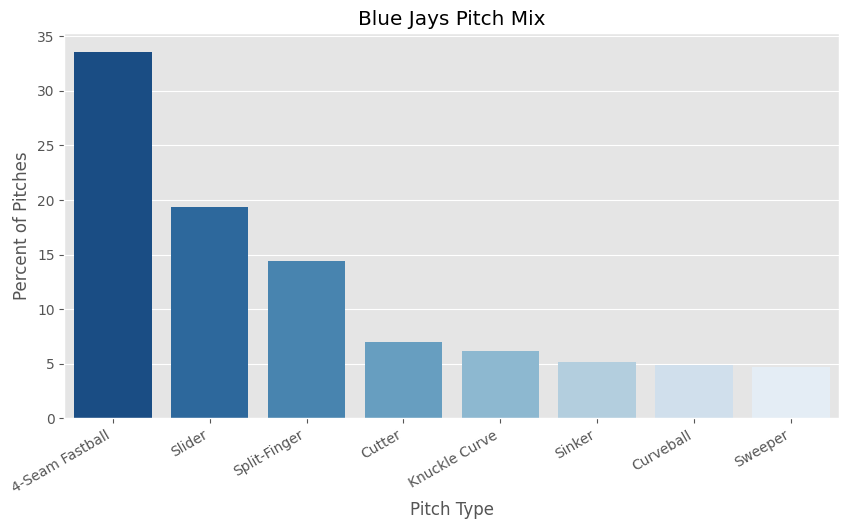

In [21]:
# EDA Block 1: Summarize the overall pitch mix.

pitch_mix = (
    bj_clean["pitch_name"]
    .value_counts()
    .rename_axis("pitch_name")
    .reset_index(name="count")
)
pitch_mix["percent"] = (pitch_mix["count"] / pitch_mix["count"].sum() * 100).round(1)

display(pitch_mix.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=pitch_mix.head(8), x="pitch_name", y="percent", palette="Blues_r")
plt.title("Blue Jays Pitch Mix")
plt.xlabel("Pitch Type")
plt.ylabel("Percent of Pitches")
plt.xticks(rotation=30, ha="right")
plt.show()

### Outcomes by Count Situation

This block compares strike rate, whiff rate, and in-play rate across the simplified count features we created earlier. It helps show how pitching outcomes change when the pitcher is ahead, behind, or working with two strikes.

,is_strike,is_whiff,is_in_play
count_leverage,,,
even,0.495,0.120,0.150
hitter_ahead,0.505,0.117,0.170
pitcher_ahead,0.368,0.165,0.173


,is_strike,is_whiff,is_in_play
has_two_strikes,,,
0,0.483,0.119,0.143
1,0.410,0.164,0.208


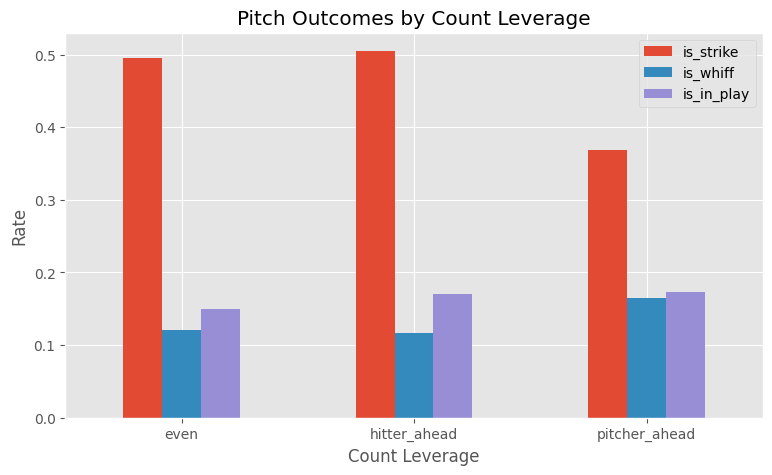

In [22]:
# EDA Block 2: Compare outcomes across count situations.

count_summary = (
    bj_clean
    .groupby("count_leverage")[["is_strike", "is_whiff", "is_in_play"]]
    .mean()
    .round(3)
    .sort_index()
)

two_strike_summary = (
    bj_clean
    .groupby("has_two_strikes")[["is_strike", "is_whiff", "is_in_play"]]
    .mean()
    .round(3)
)

display(count_summary)
display(two_strike_summary)

count_summary.plot(kind="bar", figsize=(9, 5))
plt.title("Pitch Outcomes by Count Leverage")
plt.xlabel("Count Leverage")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.show()

### High-Level Pitcher Summary

This block identifies the pitchers who threw the most pitches and summarizes a few simple performance indicators. This is useful for seeing which pitchers are most influential in the dataset and whether usage and effectiveness vary across arms.

,pitches,avg_velocity,strike_rate,whiff_rate
player_name,,,,
"Yesavage, Trey",440,89.151,0.495,0.168
"Gausman, Kevin",436,89.288,0.463,0.156
"Bieber, Shane",310,87.923,0.439,0.113
"Varland, Louis",250,93.939,0.448,0.128
"Scherzer, Max",220,89.029,0.464,0.123
"Hoffman, Jeff",207,90.855,0.498,0.155
"Domínguez, Seranthony",199,93.097,0.387,0.121
"Fluharty, Mason",138,86.644,0.514,0.145
"Lauer, Eric",136,86.903,0.478,0.066


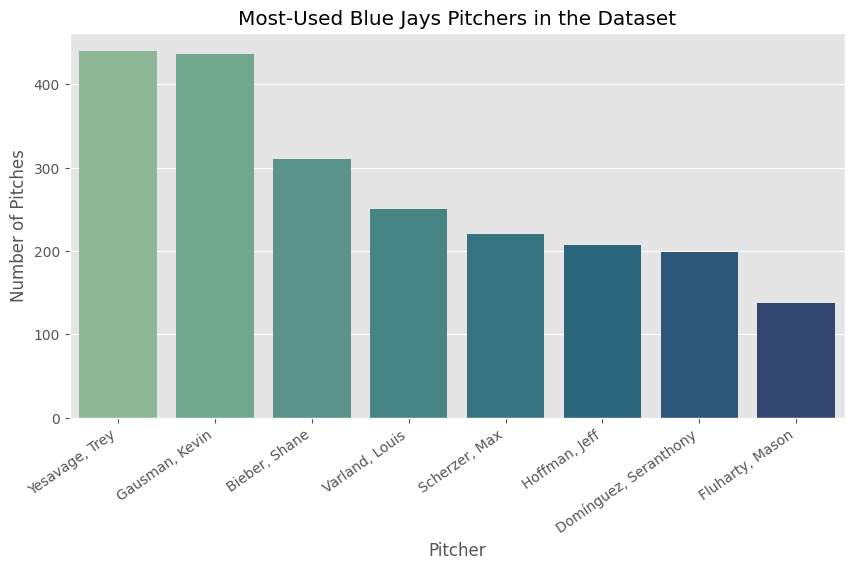

In [23]:
# EDA Block 3: Summarize the most-used pitchers.

pitcher_summary = (
    bj_clean
    .groupby("player_name")
    .agg(
        pitches=("pitch_name", "size"),
        avg_velocity=("release_speed", "mean"),
        strike_rate=("is_strike", "mean"),
        whiff_rate=("is_whiff", "mean")
    )
    .sort_values("pitches", ascending=False)
    .round(3)
)

display(pitcher_summary.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=pitcher_summary.head(8).reset_index(), x="player_name", y="pitches", palette="crest")
plt.title("Most-Used Blue Jays Pitchers in the Dataset")
plt.xlabel("Pitcher")
plt.ylabel("Number of Pitches")
plt.xticks(rotation=35, ha="right")
plt.show()

### Inning-Level Trends

This final EDA block checks whether average velocity and whiff rate change by inning. It gives us a simple first look at whether pitcher effectiveness appears to change as games progress.

,release_speed,is_whiff
inning,,
1,89.710,0.140
2,89.390,0.179
3,88.812,0.142
4,88.797,0.155
5,88.940,0.119
6,89.261,0.138
7,90.716,0.088
8,90.203,0.111
9,90.791,0.143


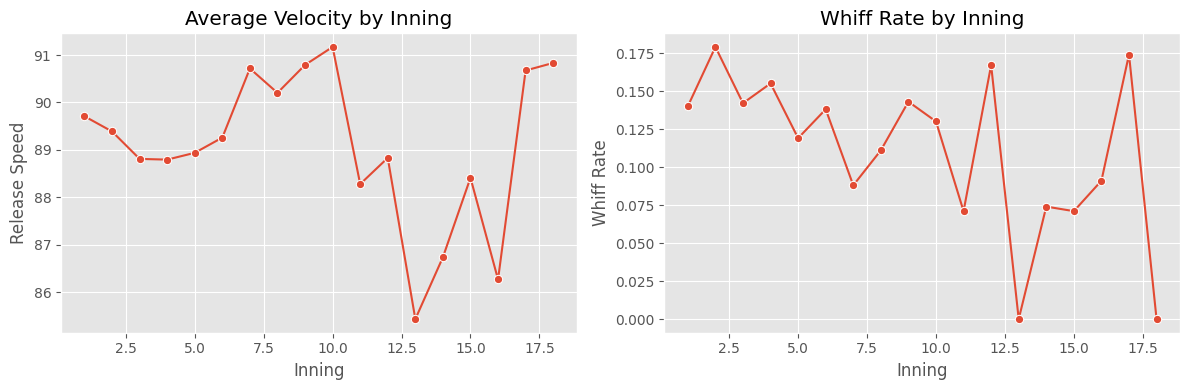

In [24]:
# EDA Block 4: Look for inning-level changes in velocity and whiff rate.

inning_summary = (
    bj_clean
    .groupby("inning")[["release_speed", "is_whiff"]]
    .mean()
    .round(3)
)

display(inning_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=inning_summary, x=inning_summary.index, y="release_speed", marker="o", ax=axes[0])
axes[0].set_title("Average Velocity by Inning")
axes[0].set_xlabel("Inning")
axes[0].set_ylabel("Release Speed")

sns.lineplot(data=inning_summary, x=inning_summary.index, y="is_whiff", marker="o", ax=axes[1])
axes[1].set_title("Whiff Rate by Inning")
axes[1].set_xlabel("Inning")
axes[1].set_ylabel("Whiff Rate")

plt.tight_layout()
plt.show()